In [1]:
import torch
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score, silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# for mapping labels
label_encoder = preprocessing.LabelEncoder()

Using device: cuda


In [2]:
phone_map = {'aa': 0, 'ae': 1, 'ah': 2, 'ao': 3, 'aw': 4, 'ax': 5, 'ax-h': 6, 'axr': 7, 
'ay': 8, 'b': 9, 'bcl': 10, 'ch': 11, 'd': 12, 'dcl': 13, 'dh': 14, 'dx': 15, 
'eh': 16, 'el': 17, 'em': 18, 'en': 19, 'eng': 20, 'epi': 21, 'er': 22, 'ey': 23, 
'f': 24, 'g': 25, 'gcl': 26, 'h#': 27, 'hh': 28, 'hv': 29, 'ih': 30, 'ix': 31, 
'iy': 32, 'jh': 33, 'k': 34, 'kcl': 35, 'l': 36, 'm': 37, 'n': 38, 'ng': 39, 
'nx': 40, 'ow': 41, 'oy': 42, 'p': 43, 'pau': 44, 'pcl': 45, 'q': 46, 'r': 47, 
's': 48, 'sh': 49, 't': 50, 'tcl': 51, 'th': 52, 'uh': 53, 'uw': 54, 'ux': 55, 
'v': 56, 'w': 57, 'y': 58, 'z': 59, 'zh': 60}

# from TIMIT PHONCODE.DOC
moa_map = {
    'stop': {'b', 'd', 'g', 'p', 't', 'k', 'dx', 'q'},
    'affricate': {'jh', 'ch'},
    'fricative': {'s', 'sh', 'z', 'zh', 'f', 'th', 'v', 'dh'},
    'nasal': {'m', 'n', 'ng', 'em', 'en', 'eng', 'nx'},
    'approximant': {'l', 'r', 'w', 'y', 'hh', 'hv', 'el'},
    'vowel': {'iy', 'ih', 'eh', 'ey', 'ae', 'aa', 'aw', 'ay', 'ah', 'ao', 'oy', 'ow', 'uh', 'uw', 'ux', 'er', 'ax', 'ix', 'axr', 'ax-h'},
    'none': {'h#', 'pau', 'epi', '1', '2'}
}

voiced_map = {
    'voiced': {'b', 'd', 'g', 'dx', 'jh', 'z', 'zh', 'v', 'dh', 'm', 'n', 'ng', 'em', 'en', 'eng', 'nx', 'l', 'r', 'w', 'y', 'el', 'iy', 'ih', 'eh', 'ey', 'ae', 'aa', 'aw', 'ay', 'ah', 'ao', 'oy', 'ow', 'uh', 'uw', 'ux', 'er', 'ax', 'ix', 'axr', 'ax-h'},
    'unvoiced': {'p', 't', 'k', 'q', 'ch', 's', 'sh', 'f', 'th', 'hh', 'hv'},
    'none': {'h#', 'pau', 'epi', '1', '2'}
}

# invert the map so we can convert from phones to manner of articulation
phone_to_moa_map = {}
for moa, phone_set in moa_map.items():
    for phone in phone_set:
        phone_to_moa_map[phone] = moa

def phone_to_moa(phone):
    if phone in phone_to_moa_map.keys():
        return phone_to_moa_map[phone]
    return 'none'

# invert the map so we can convert from phones to voicedness
phone_to_voiced_map = {}
for voicedness, phone_set in voiced_map.items():
    for phone in phone_set:
        phone_to_voiced_map[phone] = voicedness

def phone_to_voiced(phone):
    if phone in phone_to_voiced_map.keys():
        return phone_to_voiced_map[phone]
    return 'none'

In [ ]:
print("Loading saved test wav2vec embeddings...")
wav2vec_test_embeddings = torch.load('data/saved_embeddings/wav2vec_test_embeddings.pt')#[:10000]
wav2vec_test_labels = torch.load('data/saved_embeddings/wav2vec_test_labels.pt')#[:10000]

wav2vec_test_moas = list(map(phone_to_moa, wav2vec_test_labels))
wav2vec_test_voicednesses = list(map(phone_to_voiced, wav2vec_test_labels))

new_embeddings = []
new_moas = []
new_voicednesses = []
new_labels = []

# get rid of "none" segments
for i in range(len(wav2vec_test_moas)):
    if wav2vec_test_moas[i] != 'none':
        new_embeddings.append(wav2vec_test_embeddings[i])
        new_moas.append(wav2vec_test_moas[i])
        new_voicednesses.append(wav2vec_test_voicednesses[i])
        new_labels.append(wav2vec_test_labels[i])

# reassign, so it's like nothing happened c:
wav2vec_test_embeddings = new_embeddings
wav2vec_test_moas = new_moas
wav2vec_test_voicednesses = new_voicednesses
wav2vec_test_labels = new_labels

Loading saved test wav2vec embeddings...


In [13]:
scaler = StandardScaler()
wav2vec_test_embeddings = scaler.fit_transform(wav2vec_test_embeddings)

pca_50 = PCA(50)
wav2vec_test_embeddings = pca_50.fit_transform(wav2vec_test_embeddings)

print('Cumulative explained variation for 50 principal components: {}'.format(np.sum(pca_50.explained_variance_ratio_)))


Cumulative explained variation for 50 principal components: 0.8597509348184671


In [ ]:
# TSNE time c:
# scaler = StandardScaler()
# wav2vec_test_embeddings = scaler.fit_transform(wav2vec_test_embeddings)
tsneer = TSNE(n_components = 2, verbose=1, perplexity=40, random_state = 7, max_iter=100000, n_jobs=-1) # yes 100000 is kinda an insane maximum but I wanted to see, ok

tsne_data = tsneer.fit_transform(wav2vec_test_embeddings)


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 47013 samples in 0.000s...
[t-SNE] Computed neighbors for 47013 samples in 2.843s...
[t-SNE] Computed conditional probabilities for sample 1000 / 47013
[t-SNE] Computed conditional probabilities for sample 2000 / 47013
[t-SNE] Computed conditional probabilities for sample 3000 / 47013
[t-SNE] Computed conditional probabilities for sample 4000 / 47013
[t-SNE] Computed conditional probabilities for sample 5000 / 47013
[t-SNE] Computed conditional probabilities for sample 6000 / 47013
[t-SNE] Computed conditional probabilities for sample 7000 / 47013
[t-SNE] Computed conditional probabilities for sample 8000 / 47013
[t-SNE] Computed conditional probabilities for sample 9000 / 47013
[t-SNE] Computed conditional probabilities for sample 10000 / 47013
[t-SNE] Computed conditional probabilities for sample 11000 / 47013
[t-SNE] Computed conditional probabilities for sample 12000 / 47013
[t-SNE] Computed conditional probabilities for sa

In [ ]:
df = pd.DataFrame()
df['tsne_dim_1'] = tsne_data[:, 0]
df['tsne_dim_2'] = tsne_data[:, 1]
# this took me three hours to run I do NOT want to overwrite this by accident
# df.to_csv('data/wav2vec_tsne_embeddings.csv') 

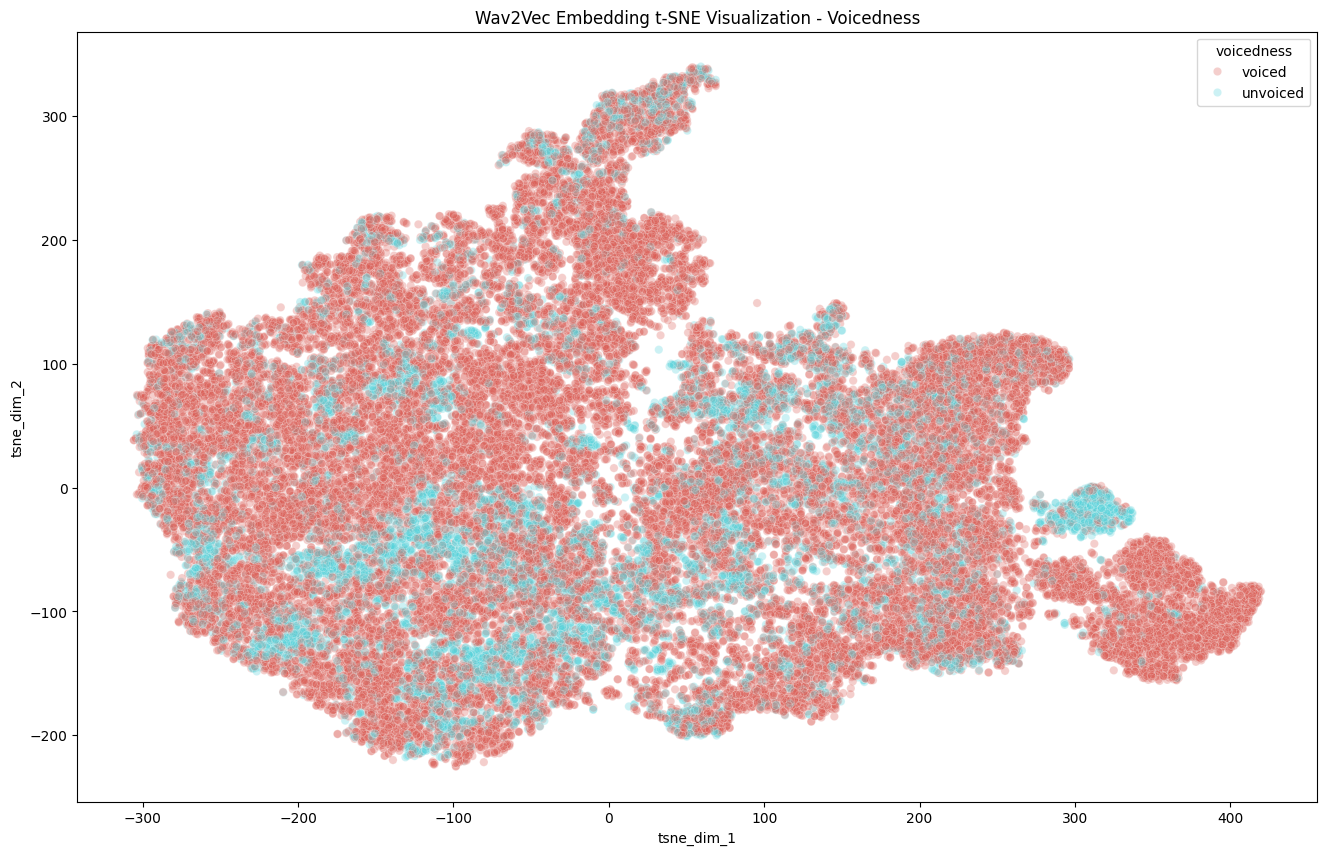

In [ ]:
# voicedness visualization
df = pd.read_csv('data/tsne_embeddings.csv')
df['manner of articulation'] = wav2vec_test_moas
df['voicedness'] = wav2vec_test_voicednesses
df['phone'] = wav2vec_test_labels
df['is vowel'] = df['manner of articulation'] == 'vowel'

plt.figure(figsize=(16,10))
seaborn.scatterplot(
    x="tsne_dim_1", y="tsne_dim_2",
    hue="voicedness",
    palette=seaborn.color_palette("hls", 2),
    data=df,
    legend="full",
    alpha=0.3
)
plt.title("Wav2Vec Embedding t-SNE Visualization - Voicedness")

plt.savefig('figures/wav2vec_voicedness_visualization.png')

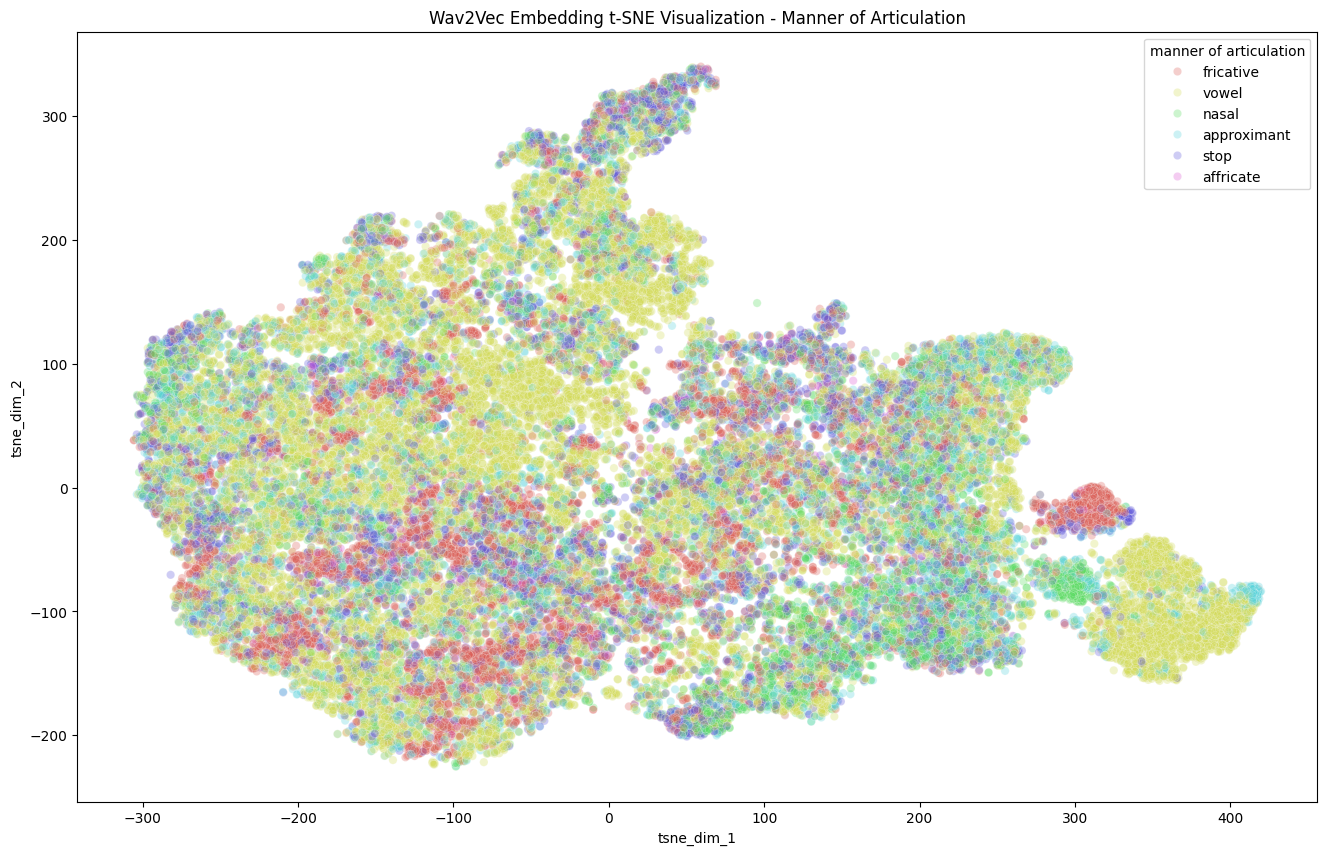

In [ ]:
plt.figure(figsize=(16,10))
seaborn.scatterplot(
    x="tsne_dim_1", y="tsne_dim_2",
    hue="manner of articulation",
    palette=seaborn.color_palette("hls", 6),
    data=df,
    legend="full",
    alpha=0.3
)
plt.title("Wav2Vec Embedding t-SNE Visualization - Manner of Articulation")

plt.savefig('figures/wav2vec_moa_visualization.png')

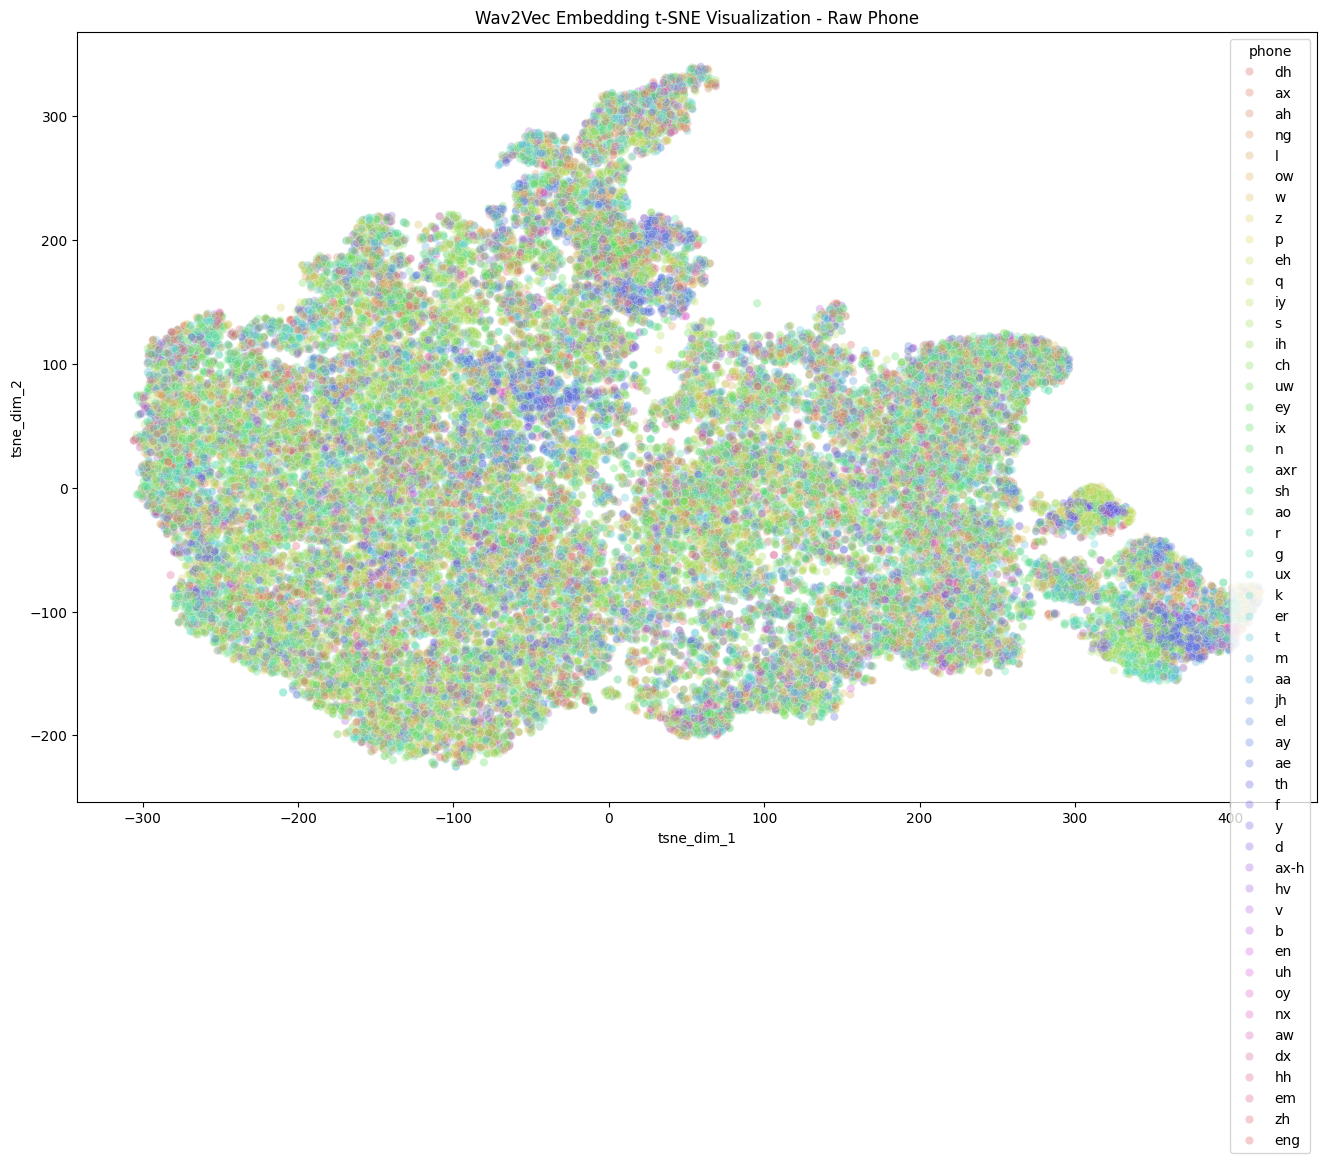

In [ ]:
plt.figure(figsize=(16,10))
seaborn.scatterplot(
    x="tsne_dim_1", y="tsne_dim_2",
    hue="is_vowel",
    palette=seaborn.color_palette("hls", 52),
    data=df,
    legend="full",
    alpha=0.3
)
plt.title("Wav2Vec Embedding t-SNE Visualization - Vowels")

plt.savefig('figures/wav2vec_vowel_visualization.png')

## The same thing, but for whisper

In [ ]:
print("Loading saved test whisper embeddings...")
whisper_test_embeddings = torch.load('data/saved_embeddings/whisper_test_embeddings.pt')#[:10000]
whisper_test_labels = torch.load('data/saved_embeddings/whisper_test_labels.pt')#[:10000]

whisper_test_moas = list(map(phone_to_moa, whisper_test_labels))
whisper_test_voicednesses = list(map(phone_to_voiced, whisper_test_labels))

new_embeddings = []
new_moas = []
new_voicednesses = []
new_labels = []

# get rid of "none" segments
for i in range(len(whisper_test_moas)):
    if whisper_test_moas[i] != 'none':
        new_embeddings.append(whisper_test_embeddings[i])
        new_moas.append(whisper_test_moas[i])
        new_voicednesses.append(whisper_test_voicednesses[i])
        new_labels.append(whisper_test_labels[i])

# reassign, so it's like nothing happened c:
whisper_test_embeddings = new_embeddings
whisper_test_moas = new_moas
whisper_test_voicednesses = new_voicednesses
whisper_test_labels = new_labels

In [ ]:
scaler = StandardScaler()
whisper_test_embeddings = scaler.fit_transform(whisper_test_embeddings)

pca_50 = PCA(50)
whisper_test_embeddings = pca_50.fit_transform(whisper_test_embeddings)

print('Cumulative explained variation for 50 principal components: {}'.format(np.sum(pca_50.explained_variance_ratio_)))


In [ ]:
# TSNE time c:
# scaler = StandardScaler()
# wav2vec_test_embeddings = scaler.fit_transform(wav2vec_test_embeddings)
whisper_tsneer = TSNE(n_components = 2, verbose=1, perplexity=40, random_state = 7, max_iter=100000, n_jobs=-1) # yes 100000 is kinda an insane maximum but I wanted to see, ok

whisper_tsne_data = whisper_tsneer.fit_transform(whisper_test_embeddings)


In [ ]:
whisper_df = pd.DataFrame()
whisper_df['tsne_dim_1'] = whisper_tsne_data[:, 0]
whisper_df['tsne_dim_2'] = whisper_tsne_data[:, 1]
whisper_df.to_csv('data/whisper_tsne_embeddings.csv') 

In [ ]:
# voicedness visualization
whisper_df = pd.read_csv('data/tsne_embeddings.csv')
whisper_df['manner of articulation'] = whisper_test_moas
whisper_df['voicedness'] = whisper_test_voicednesses
whisper_df['phone'] = whisper_test_labels
whisper_df['is vowel'] = whisper_df['manner of articulation'] == 'vowel'

plt.figure(figsize=(16,10))
seaborn.scatterplot(
    x="tsne_dim_1", y="tsne_dim_2",
    hue="voicedness",
    palette=seaborn.color_palette("hls", 2),
    data=whisper_df,
    legend="full",
    alpha=0.3
)
plt.title("Whisper Embedding t-SNE Visualization - Voicedness")

plt.savefig('figures/whisper_voicedness_visualization.png')

In [ ]:
# manner of articulation visualization
plt.figure(figsize=(16,10))
seaborn.scatterplot(
    x="tsne_dim_1", y="tsne_dim_2",
    hue="manner of articulation",
    palette=seaborn.color_palette("hls", 2),
    data=whisper_df,
    legend="full",
    alpha=0.3
)
plt.title("Whisper Embedding t-SNE Visualization - Manner of Articulation")

plt.savefig('figures/whisper_moa_visualization.png')

In [ ]:
plt.figure(figsize=(16,10))
seaborn.scatterplot(
    x="tsne_dim_1", y="tsne_dim_2",
    hue="is_vowel",
    palette=seaborn.color_palette("hls", 2),
    data=whisper_df,
    legend="full",
    alpha=0.3
)
plt.title("Whisper Embedding t-SNE Visualization - Vowels")

plt.savefig('figures/whisper_vowel_visualization.png')

In [ ]:
# TODO: I wanna try TSNE but with only vowels, so that I can try and see if there's a cleaner representation that can come out of this


In [51]:
# yeah I don't think I'm getting this part working just yet...
# print("Starting HDBSCAN fit...")
# clusterer = HDBSCAN(min_cluster_size = 50, min_samples=10)
# cluster_labels = clusterer.fit_predict(wav2vec_test_embeddings)

# n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
# n_noise = list(cluster_labels).count(-1)
# ari_score = adjusted_rand_score(wav2vec_test_voicednesses, cluster_labels)
# silhouette_avg = silhouette_score(wav2vec_test_voicednesses, cluster_labels)
# print(n_clusters, n_noise, ari_score, silhouette_avg)